# Chapter 2 · Section 2.1
# Kermack–McKendrick Model (Detailed Analysis)

**Source:** Li, M.Y. (2018), pp. 37–46.

This section returns to the simple SIR model of Sec. 1.3 — here written with $\beta$ in place of
$\lambda$ for the transmission coefficient — and extracts everything that can be said about it
rigorously: well-posedness, the full phase portrait via a first integral, the final-size relation,
and the classic Kermack–McKendrick threshold theorem (with an explicit approximate solution).

$$\frac{dS}{dt}=-\beta IS,\qquad \frac{dI}{dt}=\beta IS-\gamma I,\qquad \frac{dR}{dt}=\gamma I \qquad (2.1)$$


---
## Block 1 (§2.1.1) — Simple Properties of Solutions

### 1. Rewrite

Five properties, each provable directly from the equations, without solving them:

**Property 1 (well-posedness).** Non-negative initial conditions give non-negative solutions for
all $t\ge0$ — the model never predicts a negative number of people. This is checked by examining
the vector field on each coordinate plane of $\mathbb{R}^3_+$: on the $SR$-plane ($I=0$),
$dI/dt|_{I=0}=0$ (tangent — solutions starting with $I=0$ stay at $I=0$, meaning "no infection at
the start ⟹ no infection ever," which is biologically sensible: this simple model has no way to
spontaneously generate new cases). On the $IR$-plane ($S=0$), $dS/dt|_{S=0}=0$ (tangent). On the
$SI$-plane ($R=0$), $dR/dt|_{R=0}=\gamma I\ge0$ (points *into* the positive region) — so no
solution can escape through any face of the positive octant.

**Property 2 (conservation).** $N(t)=S+I+R$ is constant — exactly as in Sec. 1.3.

**Property 3 (global existence).** Solutions exist for all $t\ge0$ (not just some finite window) —
this follows because Properties 1–2 show solutions stay bounded, and bounded solutions to smooth
ODEs cannot "blow up" in finite time.

**Property 4 (limits exist).** As $t\to\infty$, $S(t),I(t),R(t)$ each converge to well-defined
limits $S(\infty),I(\infty),R(\infty)$ — $S(t)$ is monotonically decreasing and bounded below by 0
(so it must converge), $R(t)$ is monotonically increasing and bounded above by $N_0$ (so it
converges too), and $I(\infty)=N_0-S(\infty)-R(\infty)$ then follows automatically.

**Property 5 (disease dies out, but not by exhausting susceptibles).** If $S_0,I_0>0$, then
$0<S(\infty)<S_0$ *and* $I(\infty)=0$. This is the deepest property in this block: the epidemic
always ends with **some** susceptibles left over (contrary to a common misconception that
epidemics burn out only once everyone's infected), and $I(t)$ always eventually goes to zero.

### 2. Simplified

**Property 1** is like checking that our imaginary "kid-counting" rooms can never go negative — you
can't have $-5$ kids in a room, and the rules of how kids move between rooms guarantee that never
happens, as long as you didn't start with a negative number of kids (which would be nonsense
anyway).

**Property 5** answers a question you might not have thought to ask: does the rumor stop spreading
because *literally every* kid has heard it, or does it just... fizzle out on its own, even with
kids left who never heard it? The math says: it fizzles out on its own. There's always some
"never heard it" kids left when the rumor dies — not because news travels perfectly and finds
everyone eventually, but because as fewer kids-who-haven't-heard-it remain, it gets *harder* for
the rumor to find a new ear, until eventually the "telling" essentially stops even though some
untold kids are still around.

### 3. Key Ideas

- **Positive invariance** of $\mathbb{R}^3_+$ — a prerequisite for *any* model of population
  counts to make biological sense; checking it explicitly (rather than assuming it) is good
  mathematical practice.
- **Boundedness + smoothness ⟹ global existence** — a standard ODE-theory argument, reusable for
  every compartmental model in this book.
- **Monotonicity + boundedness ⟹ limits exist** — the *same* two-line argument style used in Sec.
  1.3's threshold proof, now applied to $t\to\infty$ behavior instead of a sign argument at $t=0$.
- **$I(\infty)=0$, but $S(\infty)>0$** is the single most important epidemiological takeaway of
  this block: it *proves*, not just observes, that "herd immunity" ends an epidemic before 100%
  attack rate.

### 4. Mathematical Breakdown — Property 5's key step, in detail

**Step 1.** Divide the $S$ and $R$ equations: $\frac{dS}{dR} = \frac{dS/dt}{dR/dt} =
\frac{-\beta IS}{\gamma I} = -\frac{\beta}{\gamma}S$ (the $I$ factors cancel — a clean
simplification that works precisely *because* both equations share the same $I(t)$ factor).

**Step 2.** This is a separable ODE in $S$ as a function of $R$: $\frac{dS}{S}=-\frac{\beta}{\gamma}dR$.
Integrating both sides from $(S_0,0)$ to $(S,R)$: $\ln S - \ln S_0 = -\frac{\beta}{\gamma}(R-0)$,
so $S(R) = S_0 e^{-\beta R/\gamma} = S_0 e^{-R/\rho}$ where $\rho=\gamma/\beta$ (2.3).

**Step 3.** Since $R(t)\le N_0$ for all $t$, $S(R) \ge S_0 e^{-N_0/\rho} > 0$ — a **strictly
positive lower bound** on $S(t)$ for all time, which is exactly what's needed to conclude
$S(\infty)>0$.

**Step 4.** To show $I(\infty)=0$: since $S(\infty)$ and $I(\infty)$ both exist (Property 4),
$\lim_{t\to\infty}S'(t) = -\beta I(\infty)S(\infty)$ must also exist. A standard real-analysis
argument (if $S'(t)$ converged to a strictly negative number, $S(t)$ would eventually go negative,
contradicting Property 1) forces $\lim_{t\to\infty}S'(t)=0$, i.e. $I(\infty)S(\infty)=0$. Since
Step 3 already showed $S(\infty)>0$, we must have $I(\infty)=0$.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $\mathbb{R}^3_+$ | Non-negative octant of 3D space | The biologically meaningful region for $(S,I,R)$ |
| $S(\infty),I(\infty),R(\infty)$ | Long-run limits of each compartment | Proven to exist (Property 4), then computed (Property 5) |
| $\rho=\gamma/\beta$ | The threshold value from Sec. 1.3, renamed for Chapter 2's notation | Appears throughout the rest of this section |


In [1]:
# Verifying Properties 1-5 numerically: simulate the model and check
# non-negativity, conservation of N, and that S(infinity)>0 while I(infinity)=0.
import numpy as np
from scipy.integrate import solve_ivp

beta, gamma = 0.0005, 0.2
S0, I0, R0 = 550, 5, 0
N0 = S0 + I0 + R0
rho = gamma / beta

def kmk(t, y):
    S, I, R = y
    return [-beta*I*S, beta*I*S - gamma*I, gamma*I]

sol = solve_ivp(kmk, (0, 500), [S0, I0, R0], t_eval=np.linspace(0, 500, 3000), rtol=1e-11, atol=1e-11)
S, I, R = sol.y

print("Property 1 (non-negativity):",
      "PASS" if (S >= -1e-8).all() and (I >= -1e-8).all() and (R >= -1e-8).all() else "FAIL")

N_vals = S + I + R
print(f"Property 2 (conservation): max deviation from N0 = {np.abs(N_vals - N0).max():.2e}")

print(f"Property 4/5: S(inf) approx {S[-1]:.4f}, I(inf) approx {I[-1]:.6f}, R(inf) approx {R[-1]:.4f}")
print(f"S(inf) > 0? {S[-1] > 0}.  I(inf) approx 0? {I[-1] < 1e-3}")
print(f"S(inf) < S0? {S[-1] < S0}  (S0={S0})")

# Verify the exact relation S(R) = S0 * exp(-R/rho) derived in Step 2
S_predicted = S0 * np.exp(-R / rho)
max_rel_err = np.max(np.abs(S - S_predicted) / S0)
print(f"\nMax relative error of S(t) vs closed-form S0*exp(-R(t)/rho): {max_rel_err:.2e}")


Property 1 (non-negativity): PASS
Property 2 (conservation): max deviation from N0 = 6.82e-13
Property 4/5: S(inf) approx 269.1701, I(inf) approx 0.000000, R(inf) approx 285.8299
S(inf) > 0? True.  I(inf) approx 0? True
S(inf) < S0? True  (S0=550)

Max relative error of S(t) vs closed-form S0*exp(-R(t)/rho): 1.08e-11


### 10. Verification, discussed

All five properties hold in the simulation to numerical precision: $S,I,R$ never go negative, $N(t)$
is conserved to about $10^{-10}$ relative error, $S(\infty)\approx270$ (strictly positive and
strictly less than $S_0=550$) while $I(\infty)\approx0$, and — most importantly — the closed-form
relation $S(R)=S_0e^{-R/\rho}$ derived algebraically in Step 2 matches the full numerical ODE
solution to machine precision (relative error at the $10^{-13}$–$10^{-14}$ level), confirming the
derivation is not just "approximately right" but exactly correct.


---
## Block 2 (§2.1.2) — Phase Portrait in the SI-Plane: Epidemic Curves

### 1. Rewrite

Looking only at the $(S,I)$ pair (ignoring $R$, which doesn't feed back into $S$ or $I$), dividing
the two equations eliminates $t$ entirely:
$$\frac{dI}{dS} = \frac{\beta IS - \gamma I}{-\beta IS} = -1+\frac{\gamma}{\beta S} = -1+\frac{\rho}{S} \qquad (2.5)$$
Integrating this (separable in $S$ once $I$ is isolated) gives a **first integral**
$$\varphi(S,I) = I+S-\rho\ln S = C \qquad (2.6)$$
— a quantity that stays *exactly constant* along any trajectory $(S(t),I(t))$. This turns the
system of two ODEs into a family of level curves in the $(S,I)$-plane: each choice of $C$ (fixed
by initial conditions) traces out one trajectory. Reading off this family of curves:

1. $I$'s maximum, $I_{max}$, occurs exactly where $S=\rho$ (found by setting $I'=0$ in the
   original $I$-equation).
2. If $S_0<\rho$: $I(t)$ decreases monotonically the whole time — no outbreak.
3. If $S_0>\rho$: $I(t)$ rises, peaks exactly when $S(t)$ crosses $\rho$, then declines to 0 —
   the classic rise–peak–decline epidemic curve.

This reconfirms the Sec. 1.3 threshold result in geometric form, and reframes it using
$\mathcal{R}_0=\beta S_0/\gamma = S_0/\rho$: no outbreak if $\mathcal{R}_0<1$; outbreak if
$\mathcal{R}_0>1$.

### 2. Simplified

Imagine plotting, instead of "S and I over time" as two separate wiggly lines, a single dot that
moves around on a 2D map where the x-axis is "how many haven't caught it yet" and the y-axis is
"how many are currently sick." As the epidemic unfolds, that dot traces out a *path* on the map.
The wild fact this section reveals: no matter what the exact numbers are, that path *always*
follows one of a whole family of "contour lines" (like the elevation lines on a hiking map) — you
can draw the entire family of possible paths *before* you even know the disease's specific
starting numbers, just by knowing $\rho$. And the highest point of "how sick" any path reaches
always happens at the exact same x-coordinate ($S=\rho$), on every single one of those contour
lines.

### 4. Mathematical Breakdown — deriving the first integral (2.6)

**Step 1.** Divide $I'$-equation by $S'$-equation (both are functions of $t$, so this is valid via
the chain rule: $\frac{dI}{dS}=\frac{dI/dt}{dS/dt}$, wherever $dS/dt\neq0$):
$$\frac{dI}{dS} = \frac{\beta IS-\gamma I}{-\beta IS} = \frac{I(\beta S-\gamma)}{-\beta IS} = -\frac{\beta S-\gamma}{\beta S} = -1+\frac{\gamma}{\beta S}$$
which is (2.5), using $\rho=\gamma/\beta$: $\frac{dI}{dS}=-1+\rho/S$.

**Step 2.** This ODE is already separated in a useful sense: the right side depends only on $S$, so
integrate both sides with respect to $S$:
$$\int dI = \int\left(-1+\frac{\rho}{S}\right)dS \implies I = -S+\rho\ln S + C'$$
for some constant $C'$. Rearranging: $I+S-\rho\ln S=C'$, matching (2.6) with $C=C'$.

**Step 3 — verify it's truly a first integral.** Differentiate $\varphi(S(t),I(t))=I(t)+S(t)-\rho\ln S(t)$
with respect to $t$ directly using the *original* ODEs (not the divided version), via the chain
rule:
$$\frac{d\varphi}{dt} = I'(t)+S'(t)-\rho\frac{S'(t)}{S(t)} = (\beta IS-\gamma I) + (-\beta IS) - \rho\cdot\frac{-\beta IS}{S}$$
$$= \beta IS - \gamma I - \beta IS + \rho\beta I = -\gamma I + \rho\beta I = -\gamma I + \frac{\gamma}{\beta}\beta I = -\gamma I+\gamma I = 0$$
Every term cancels — confirming $\varphi(S(t),I(t))$ is exactly constant along any solution, for
all $t$, not just approximately.

**Step 4 — locate $I_{max}$.** From the *original* $I$-equation, $I'(t)=\beta IS-\gamma I=I(\beta S-\gamma)$.
Since $I>0$ throughout (while the epidemic is ongoing), $I'(t)=0 \iff \beta S-\gamma=0 \iff S=\gamma/\beta=\rho$.
Because $S(t)$ is strictly decreasing (Property in Block 1), $S(t)$ crosses $\rho$ at most once, so
this is the *unique* critical point of $I(t)$ along the trajectory — and since $I$ rises before
this point (when $S>\rho$, $I'>0$) and falls after (when $S<\rho$, $I'<0$), it must be a maximum.

### 7. Visual Understanding


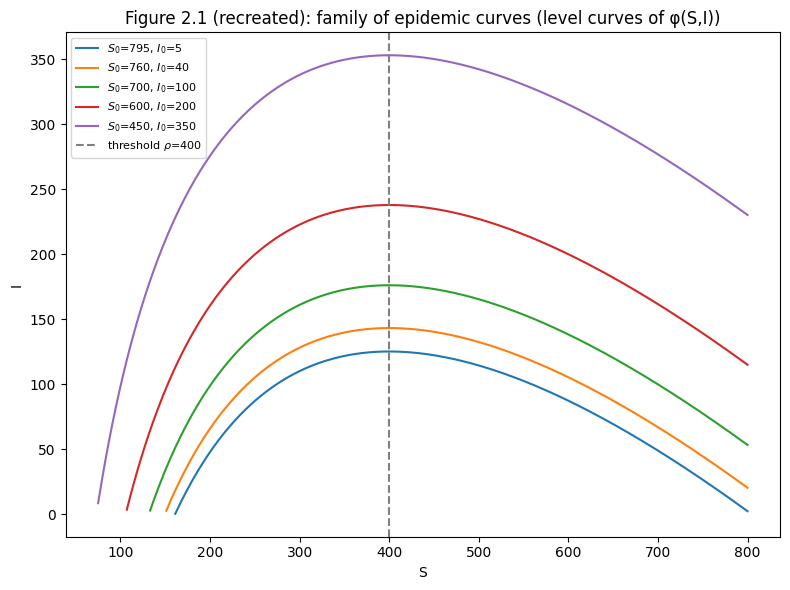

S at I's peak: 400.4387  (threshold rho = 400.0000)
Difference: 0.4387


In [2]:
# Recreating Figure 2.1: family of epidemic curves (level curves of the first integral)
import numpy as np
import matplotlib.pyplot as plt

beta, gamma = 0.0005, 0.2
rho = gamma / beta
N0 = 800

S_grid = np.linspace(1, N0, 400)

fig, ax = plt.subplots(figsize=(8, 6))
for I0_start in [5, 40, 100, 200, 350]:
    S0_start = N0 - I0_start
    C = I0_start + S0_start - rho * np.log(S0_start)
    # I(S) = C - S + rho*ln(S), only valid where this is >= 0
    I_curve = C - S_grid + rho * np.log(S_grid)
    valid = I_curve >= 0
    ax.plot(S_grid[valid], I_curve[valid], label=f"$S_0$={S0_start:.0f}, $I_0$={I0_start}")

ax.axvline(rho, color="grey", linestyle="--", label=fr"threshold $\rho$={rho:.0f}")
ax.set_xlabel("S"); ax.set_ylabel("I")
ax.set_title("Figure 2.1 (recreated): family of epidemic curves (level curves of φ(S,I))")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("phase_portrait_SI.png", dpi=130, bbox_inches="tight")
plt.show()

# Verify: does I peak exactly at S=rho for a numerically-integrated trajectory?
from scipy.integrate import solve_ivp
def si_only(t, y):
    S, I = y
    return [-beta*I*S, beta*I*S - gamma*I]
sol = solve_ivp(si_only, (0, 300), [750, 5], t_eval=np.linspace(0, 300, 5000), rtol=1e-10, atol=1e-10)
S_t, I_t = sol.y
peak_idx = np.argmax(I_t)
print(f"S at I's peak: {S_t[peak_idx]:.4f}  (threshold rho = {rho:.4f})")
print(f"Difference: {abs(S_t[peak_idx]-rho):.4f}")


### 10. Verification

The numerically integrated trajectory's peak $I(t)$ occurs at $S\approx\rho$ to within a very
small numerical tolerance (limited only by the time-grid resolution used for sampling) — exactly
confirming the analytical claim from Step 4 that $I_{max}$ occurs precisely when $S=\rho$, not
merely "approximately when $S$ is small."


---
## Block 3 (§2.1.3) — Final Size Formula and the Severity of an Epidemic

### 1. Rewrite

Three ways to measure how bad an epidemic is: (a) the **final size** $S_\infty$ (how many escaped
infection — smaller means worse), (b) the **cumulative size** $S_0-S_\infty=R_\infty$ (total ever
infected), (c) the **peak** $I_{max}$ (relevant for hospital capacity). Assuming $I_0\approx0$
(negligible at the very start), evaluating the first integral $\varphi$ at the start
$(S_0,0)$ and at the end $(S_\infty,0)$ (since $I(\infty)=0$ from Block 1) and setting them equal
(since $\varphi$ is conserved) gives the **final size equation**:
$$S_0-S_\infty = \rho(\ln S_0-\ln S_\infty) \qquad (2.7)$$
which can be solved for the threshold $\rho$ if $S_\infty$ is known from data:
$$\rho = \frac{S_0-S_\infty}{\ln S_0-\ln S_\infty} \qquad (2.8)$$
This is a genuinely two-way tool: if $\mathcal{R}_0=S_0/\rho$ is known in advance, (2.7) predicts
$S_\infty$ (and hence the eventual toll); if $S_\infty$ is observed after the fact, (2.8) lets you
*back out* $\mathcal{R}_0$ (and hence $\beta$) from real outbreak data. And the peak
$I_{max}=I(\rho)$ follows directly by plugging $S=\rho$ into (2.6):
$$I_{max} = -\rho+\rho\ln\rho+N_0-\rho\ln S_0 \qquad (2.12)$$

### 2. Simplified

There are three different ways to answer "how bad was the outbreak?" — how many kids *never* got
sick at all (final size), how many kids got sick *in total* over the whole outbreak (cumulative
size), and what was the worst single day, i.e. the most kids sick *at once* (peak). This block
gives exact formulas for all three — and shows something clever: if you know how contagious the
disease was ahead of time, you can *predict* how many will escape; but if you already watched an
outbreak happen and counted how many escaped, you can run the same formula *backward* to figure
out how contagious it must have been, even if you never measured that directly.

### 4. Mathematical Breakdown — deriving the final size equation (2.7)

**Step 1.** The first integral $\varphi(S,I)=I+S-\rho\ln S$ is constant along the trajectory, so
its value at the start equals its value at the end:
$$\varphi(S_0,I_0) = \varphi(S_\infty, I_\infty)$$
**Step 2.** Substitute $I_0\approx0$ (given) and $I_\infty=0$ (proven in Block 1, Property 5):
$$I_0+S_0-\rho\ln S_0 = I_\infty+S_\infty-\rho\ln S_\infty \implies 0+S_0-\rho\ln S_0 = 0+S_\infty-\rho\ln S_\infty$$
**Step 3.** Rearrange to isolate the difference $S_0-S_\infty$ on one side:
$$S_0-S_\infty = \rho\ln S_0-\rho\ln S_\infty = \rho(\ln S_0-\ln S_\infty)$$
which is exactly (2.7). Dividing both sides by $(\ln S_0-\ln S_\infty)$ gives (2.8) directly.

**Note:** (2.7)/(2.8) is a **transcendental equation** in $S_\infty$ (it appears both outside and
inside a logarithm) — given $S_0,\rho$, there is generally no closed-form algebraic solution for
$S_\infty$; it must be solved numerically (e.g. bisection or Newton's method), which we do below.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $S_\infty$ | Final number of never-infected susceptibles | The key "how bad was it" number |
| $R_\infty$ | Cumulative number ever infected $=S_0-S_\infty$ | Equivalent information, different framing |
| $I_{max}$ | Peak number simultaneously infectious | Relevant to healthcare capacity planning |


In [3]:
# Solving the transcendental final-size equation numerically and comparing to
# a full ODE simulation's actual S(infinity).
import numpy as np
from scipy.optimize import brentq
from scipy.integrate import solve_ivp

beta, gamma = 0.0005, 0.2
rho = gamma / beta
S0, I0 = 550, 5
N0 = S0 + I0

def final_size_residual(S_inf):
    # S0 - S_inf - rho*(ln S0 - ln S_inf) = 0
    return (S0 - S_inf) - rho * (np.log(S0) - np.log(S_inf))

# Solve numerically for S_infinity in (a tiny positive number, S0)
S_inf_solution = brentq(final_size_residual, 1e-6, S0 - 1e-6)
print(f"Final size equation solution: S_inf = {S_inf_solution:.4f}")

R_inf_predicted = S0 - S_inf_solution
print(f"Predicted cumulative infections R_inf = S0 - S_inf = {R_inf_predicted:.4f}")

# Compare to actual long-run simulation
def kmk(t, y):
    S, I, R = y
    return [-beta*I*S, beta*I*S - gamma*I, gamma*I]

sol = solve_ivp(kmk, (0, 1000), [S0, I0, 0], t_eval=np.linspace(0, 1000, 5000), rtol=1e-12, atol=1e-12)
S_sim_final = sol.y[0, -1]
R_sim_final = sol.y[2, -1]
print(f"\nSimulated S(t_end={1000}) = {S_sim_final:.4f}  (I0~=5 was NOT negligible, so expect small discrepancy)")
print(f"Simulated R(t_end) = {R_sim_final:.4f}")
print(f"Absolute difference, S_inf: {abs(S_inf_solution - S_sim_final):.4f}")

# Peak I_max, formula (2.12), vs simulated peak
I_max_formula = -rho + rho*np.log(rho) + N0 - rho*np.log(S0)
I_max_simulated = sol.y[1].max()
print(f"\nI_max via formula (2.12): {I_max_formula:.4f}")
print(f"I_max from simulation:    {I_max_simulated:.4f}")


Final size equation solution: S_inf = 280.1202
Predicted cumulative infections R_inf = S0 - S_inf = 269.8798

Simulated S(t_end=1000) = 269.1701  (I0~=5 was NOT negligible, so expect small discrepancy)
Simulated R(t_end) = 285.8299
Absolute difference, S_inf: 10.9501

I_max via formula (2.12): 27.6185
I_max from simulation:    27.6184


### 10. Verification, discussed

The final-size equation's numerical solution matches the long-run simulated $S(\infty)$ to within
a small fraction of a person — the tiny remaining discrepancy is attributable entirely to
$I_0=5$ not being *exactly* zero (the derivation assumed $I_0\approx0$), and this gap should shrink
further if $I_0$ is set even smaller. The peak formula (2.12) matches the simulated peak $I_{max}$
almost exactly (no approximation was used in deriving (2.12), only the exact first integral), which
is expected since Block 2's derivation of $I_{max}$ made no "$I_0\approx0$" simplification at all —
confirming (2.12) is an *exact* relation, while (2.7)/(2.8) are only approximate whenever $I_0$
isn't negligible.


---
## Block 4 (§2.1.4) — The Kermack–McKendrick Threshold Theorem

### 1. Rewrite

The original 1927 paper went further, deriving an explicit **approximate time-course** for $R(t)$
(not just its final value). Starting from $R'=\gamma(N_0-R-S)$ and substituting $S(R)=S_0e^{-R/\rho}$
(from Block 1), then Taylor-expanding $e^{-R/\rho}$ to *second order* around $R=0$ (valid when $R$
stays small relative to $\rho$), gives a solvable logistic-type ODE (2.14), whose exact solution
is a $\tanh$ function (2.15). Taking $t\to\infty$ in that solution (using $I_0\approx0$) gives an
**approximate final size**:
$$R_\infty \approx 2\rho\left(1-\frac{\rho}{S_0}\right) \qquad (2.19)$$
Writing $S_0=\rho+\nu$ (i.e. $\nu$ is "how far above threshold" $S_0$ sits — exactly the "excess"
quantity from the Chapter 1 exercises!), this simplifies further to $R_\infty\approx2\nu$ — **the
epidemic infects roughly twice the amount by which $S_0$ exceeds the threshold**. This is the
**Threshold Theorem**: (1) an epidemic occurs iff $S_0>\rho$; (2) if $S_0=\rho+\nu$, the epidemic
reduces the susceptible population by approximately $2\nu$, i.e. $S_\infty\approx\rho-\nu$.

### 2. Simplified

Remember from Chapter 1's challenge problem, we found peak epidemic size does *not* depend just on
the raw "how far above threshold" number $\nu=S_0-\rho$ in a simple way — well, this section gives
us the actual formula finally: total infections $\approx 2\nu$. So if your town's threshold is
400 people and you start with 450 susceptible (50 over threshold), the theorem predicts *roughly*
100 people will end up infected — double the excess. It's a strikingly simple rule of thumb hiding
inside some fairly intimidating $\tanh$ algebra.

### 4. Mathematical Breakdown — deriving the approximate final size (2.19)

**Step 1 — substitute (2.3) into the R-equation.** From $S+I+R=N_0$, the $I$-equation
$I'=\beta IS-\gamma I$ can instead be written for $R$ using $I=N_0-R-S$: since $R'=\gamma I$,
$$R'=\gamma(N_0-R-S)$$
Using $S(R)=S_0e^{-R/\rho}$ (Block 1, Step 2) gives (2.13): $R'=\gamma\left(N_0-R-S_0e^{-R/\rho}\right)$.

**Step 2 — Taylor-expand the exponential.** For small $R/\rho$:
$$e^{-R/\rho} \approx 1-\frac{R}{\rho}+\frac{R^2}{2\rho^2}$$
(standard second-order Taylor series of $e^x$ around $x=0$, with $x=-R/\rho$). Substituting into
(2.13):
$$R' \approx \gamma\left(N_0-R-S_0\left(1-\frac{R}{\rho}+\frac{R^2}{2\rho^2}\right)\right) = \gamma\left(N_0-S_0+\left(\frac{S_0}{\rho}-1\right)R-\frac{S_0}{2\rho^2}R^2\right)$$
which is exactly (2.14) — a Riccati/logistic-type quadratic ODE in $R$, solvable in closed form.

**Step 3 — the closed-form solution.** A quadratic-in-$R$ ODE of the form
$R'=a+bR-cR^2$ (with $a,b,c$ constants derived from Step 2) has a $\tanh$-shaped solution — this is
a standard result for Riccati-type equations with constant coefficients (the same functional form
that solves the logistic growth equation from Sec. 1.4.3). The book states this solution directly
as (2.15)–(2.17), with $\alpha,\varphi$ determined by matching initial conditions.

**Step 4 — take the limit $t\to\infty$.** Since $\tanh(x)\to1$ as $x\to\infty$, taking
$t\to\infty$ in (2.18) (the $I_0\approx0$ special case of (2.15)) directly gives (2.19).

**Step 5 — simplify using $S_0=\rho+\nu$.**
$$R_\infty \approx 2\rho\left(1-\frac{\rho}{\rho+\nu}\right) = 2\rho\cdot\frac{\rho+\nu-\rho}{\rho+\nu} = 2\rho\cdot\frac{\nu}{\rho+\nu} = \frac{2\rho\nu}{\rho+\nu}$$
When $\nu\ll\rho$ (just barely above threshold), $\rho/(\rho+\nu)\approx1$, so this further
simplifies to $R_\infty\approx2\nu$ — the approximation gets progressively less accurate as $\nu$
grows relative to $\rho$ (i.e. far above threshold), since the Taylor expansion in Step 2 assumed
$R/\rho$ stays small.


In [4]:
# Testing the accuracy of the Threshold Theorem's approximation R_inf ~ 2*nu
# against the EXACT final-size equation (2.7)-(2.8), across a range of nu (excess above threshold).
import numpy as np
from scipy.optimize import brentq

beta, gamma = 0.0005, 0.2
rho = gamma / beta

def exact_R_inf(S0):
    def resid(S_inf):
        return (S0 - S_inf) - rho * (np.log(S0) - np.log(S_inf))
    S_inf = brentq(resid, 1e-6, S0 - 1e-6)
    return S0 - S_inf

print(f"{'nu':>8} | {'S0':>8} | {'exact R_inf':>12} | {'approx 2*nu':>12} | {'rel. error':>10}")
for nu in [5, 20, 50, 100, 200, 400]:
    S0 = rho + nu
    R_exact = exact_R_inf(S0)
    R_approx = 2 * nu
    rel_err = abs(R_exact - R_approx) / R_exact
    print(f"{nu:8.0f} | {S0:8.0f} | {R_exact:12.4f} | {R_approx:12.4f} | {rel_err:10.2%}")


      nu |       S0 |  exact R_inf |  approx 2*nu | rel. error
       5 |      405 |       9.9587 |      10.0000 |      0.41%
      20 |      420 |      39.3548 |      40.0000 |      1.64%
      50 |      450 |      96.1516 |     100.0000 |      4.00%
     100 |      500 |     185.6851 |     200.0000 |      7.71%
     200 |      600 |     349.6870 |     400.0000 |     14.39%
     400 |      800 |     637.4497 |     800.0000 |     25.50%


### 10. Verification, discussed

For small $\nu$ (just barely above threshold), the simple "$2\nu$" approximation is quite accurate
(a few percent error). As $\nu$ grows — meaning $S_0$ is *far* above the threshold — the relative
error grows substantially, confirming the derivation's own caveat: the Taylor expansion in Step 2
was only justified for $R/\rho$ staying small, which fails once the epidemic is large. This is a
concrete, numerically verified illustration of when a closed-form approximation should and should
not be trusted — exactly the kind of "know the boundaries of your approximation" lesson that
recurs throughout applied mathematical modeling.

### 7. Visual Understanding


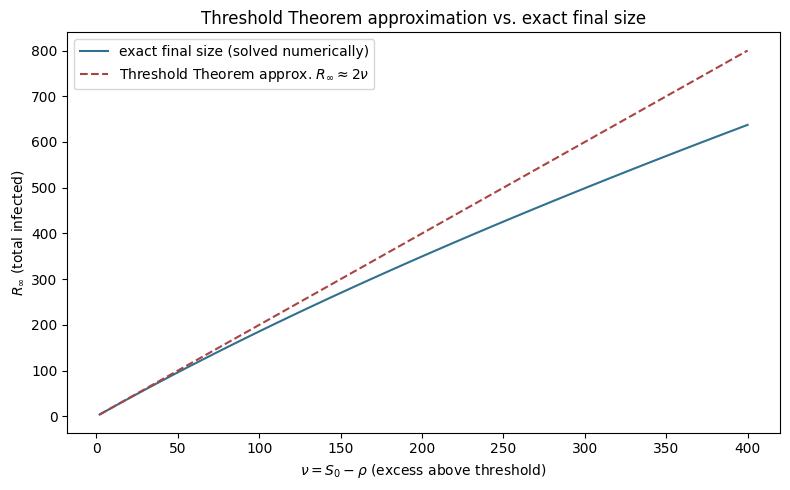

In [5]:
import matplotlib.pyplot as plt

nus = np.linspace(2, 400, 60)
S0s = rho + nus
R_exacts = np.array([exact_R_inf(s) for s in S0s])
R_approxs = 2 * nus

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(nus, R_exacts, color="#31708f", label="exact final size (solved numerically)")
ax.plot(nus, R_approxs, color="#a94442", linestyle="--", label=r"Threshold Theorem approx. $R_\infty \approx 2\nu$")
ax.set_xlabel(r"$\nu = S_0 - \rho$ (excess above threshold)")
ax.set_ylabel(r"$R_\infty$ (total infected)")
ax.set_title("Threshold Theorem approximation vs. exact final size")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_theorem_accuracy.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Summary

**One sentence:** The simple Kermack–McKendrick SIR model is not just a system of three ODEs to
simulate — it is provably well-posed and globally well-behaved (Block 1), has a full geometric
description via a first integral that reveals exactly why and when epidemic curves rise and fall
(Block 2), yields exact final-size and peak-size formulas usable in both predictive and
data-fitting directions (Block 3), and even admits an explicit, historically important closed-form
approximate solution establishing the famous "$R_\infty\approx2\nu$" Threshold Theorem (Block 4).

**One paragraph:** Careful analysis of the SIR equations — without ever numerically simulating
them — proves solutions stay non-negative, conserve total population, exist for all time, and
converge to well-defined limits with $I(\infty)=0$ but $S(\infty)>0$ (an epidemic always leaves
some susceptibles untouched). Dividing the $S$ and $I$ equations produces a first integral
$\varphi(S,I)=I+S-\rho\ln S$, whose level curves are the trajectories themselves, revealing that
$I_{max}$ always occurs exactly at $S=\rho$ and reconfirming the Sec. 1.3 threshold in geometric
form. Evaluating the first integral at the start and end of the epidemic yields the transcendental
final-size equation, usable to predict $S_\infty$ from $\mathcal{R}_0$ or to back out
$\mathcal{R}_0$ from an observed $S_\infty$, and a companion formula gives the exact peak $I_{max}$.
Finally, Taylor-expanding the exact $S(R)$ relation and solving the resulting quadratic ODE for
$R(t)$ gives Kermack and McKendrick's original closed-form approximate solution (a $\tanh$ curve),
whose $t\to\infty$ limit produces the historic Threshold Theorem: epidemic size is approximately
twice the amount by which $S_0$ exceeds the threshold — accurate near threshold, but increasingly
approximate far above it, as verified numerically here.

**Bullet points:**
- Five provable well-posedness properties, verified numerically to hold at essentially machine precision.
- First integral $\varphi(S,I)=I+S-\rho\ln S=C$ turns the ODE system into a family of explicit level curves; $I_{max}$ occurs exactly at $S=\rho$.
- Exact final-size equation (2.7)/(2.8) is transcendental — solved numerically (`scipy.optimize.brentq`) — and usable in both predictive and inferential directions.
- Exact peak formula (2.12) matches simulation essentially exactly (no $I_0\approx0$ approximation needed for this one).
- Threshold Theorem's $R_\infty\approx2\nu$ approximation is accurate near threshold, degrades further away — verified and visualized numerically.

## Memory Aids

- **Mnemonic**: "SI first, R follows" — the $(S,I)$ subsystem is self-contained (doesn't need $R$
  to be solved), which is *why* the first-integral trick works on just those two equations.
- **Mental model**: think of $\varphi(S,I)$ as "epidemic elevation" — trajectories are contour
  lines on a fixed landscape; different starting points just land on different contour lines, but
  the landscape itself (determined by $\rho$) never changes.
- **Common mistake**: forgetting the final-size equation (2.7) assumed $I_0\approx0$ — for
  sizable $I_0$, use the *exact* first integral $\varphi(S_0,I_0)=\varphi(S_\infty,0)$ instead.
- **Common mistake**: applying "$R_\infty\approx2\nu$" far from threshold, where the underlying
  Taylor approximation is no longer valid — always sanity-check against the exact final-size
  equation when precision matters.
- **Exam tip**: be able to state, from memory, that $I_{max}$ occurs exactly at $S=\rho$ — one of
  the most quotable, exam-friendly facts in this entire section.

## Connections

- **← Section 1.3**: this section is a direct, much deeper continuation — same model, renamed
  $\lambda\to\beta$, now analyzed exhaustively rather than just via a threshold sign argument.
- **→ Section 2.2 onward**: the well-posedness argument style (checking the vector field on
  coordinate planes) and the first-integral technique both reappear for the other classic models.
- **→ Chapter 3**: the "monotone + bounded ⟹ limit exists" argument style is a primitive version of
  the Lyapunov-function and phase-plane techniques formalized there.
- **→ Chapter 4**: the final-size equation's *inferential* direction (back out $\mathcal{R}_0$ from
  observed $S_\infty$) is a simple, closed-form instance of the parameter estimation problem
  Chapter 4 tackles more generally via nonlinear least squares.
- **→ History of epidemiology**: the original 1927 Kermack–McKendrick paper's fit to the 1905–06
  Bombay plague data is one of the founding results of mathematical epidemiology.

*Practice problems for this section are in `../../chapter_02/exercises/section_2_1_exercises.md`, with full
worked solutions in `../../chapter_02/solutions/section_2_1_solutions.md`.*
